# Seq2Seq (Sequence-to-Sequence)

### Embedding Vector 준비
1. 영어 glove 임베딩 (사전 학습) 사용
2. 한국어 임베딩 (초기훈련)

### 학습 데이터 준비

http://www.manythings.org/anki/

1. Encoder 입력 데이터 eng
    - encoder_input_eng 준비 `I love you`
2. Decoder 출력 데이터 kor
    - 학습용 teacher-forcing 모델
        - decoder_input_kor `<sos> 난 널 사랑해`
        - docoder_output_kor `난 널 사랑해 <eos>`
    - 추론용 모델

In [33]:
!gdown 1oEViAatKvMI8JOAgg6gJa8eS3h8Kn53z

Downloading...
From (original): https://drive.google.com/uc?id=1oEViAatKvMI8JOAgg6gJa8eS3h8Kn53z
From (redirected): https://drive.google.com/uc?id=1oEViAatKvMI8JOAgg6gJa8eS3h8Kn53z&confirm=t&uuid=b71c58a2-28a5-4db3-8a40-7e4d1b357a1c
To: c:\Users\SJ\OneDrive\Desktop\study\NLP\07_seq2seq\glove.6B.100d.txt

  0%|          | 0.00/347M [00:00<?, ?B/s]
  0%|          | 524k/347M [00:00<01:52, 3.07MB/s]
  0%|          | 1.57M/347M [00:00<00:59, 5.80MB/s]
  1%|          | 3.15M/347M [00:00<00:42, 8.03MB/s]
  1%|▏         | 4.72M/347M [00:00<00:35, 9.72MB/s]
  2%|▏         | 6.29M/347M [00:00<00:29, 11.4MB/s]
  2%|▏         | 7.86M/347M [00:00<00:27, 12.4MB/s]
  3%|▎         | 9.44M/347M [00:00<00:25, 13.3MB/s]
  3%|▎         | 11.0M/347M [00:01<00:25, 13.1MB/s]
  4%|▎         | 12.6M/347M [00:01<00:25, 13.1MB/s]
  4%|▍         | 14.7M/347M [00:01<00:24, 13.8MB/s]
  5%|▍         | 16.3M/347M [00:01<00:23, 13.8MB/s]
  5%|▌         | 17.8M/347M [00:01<00:23, 13.9MB/s]
  6%|▌         | 19.9M/347M 

In [34]:
!gdown 17-luLRrDsnP_yIzIchd3aCo_WMt4znPF -O eng_kor.txt

Downloading...
From: https://drive.google.com/uc?id=17-luLRrDsnP_yIzIchd3aCo_WMt4znPF
To: c:\Users\SJ\OneDrive\Desktop\study\NLP\07_seq2seq\eng_kor.txt

  0%|          | 0.00/864k [00:00<?, ?B/s]
 61%|██████    | 524k/864k [00:00<00:00, 2.75MB/s]
100%|██████████| 864k/864k [00:00<00:00, 3.55MB/s]


In [35]:
# 데이터 정제
eng_inputs = []  # 영어 원문 리스트
kor_inputs = []  # 한국어 입력 시트드 (디코더 입력 : <sos> 시작토큰 포함)
kor_targets = [] # 한국어 타겟 (디코더 정답: <eos> 종료토큰 포함)

with open('eng_kor.txt', 'r', encoding = 'utf-8') as f:
    for line in f:
        eng, kor, _ = line.split('\t') # line 형태 : 영어\t한국어\t(기타)

        kor_input = '<sos> ' + kor     # 디코더 입력 시작토큰 추가
        kor_target = kor + ' <eos>'    # 디코더 타겟 종료토큰 추가

        eng_inputs.append(eng)         
        kor_inputs.append(kor_input)
        kor_targets.append(kor_target)

len(eng_inputs), len(kor_inputs), len(kor_targets) # 문서 길이와 동일 : 5890

(5890, 5890, 5890)

In [36]:
# 2500 ~ 2504 인덱스 정보 확인 (전처리 확인)
print(eng_inputs[2500:2505])  
print(kor_inputs[2500:2505])
print(kor_targets[2500:2505])

['I speak French a little.', 'I take back what I said.', 'I tried to make friends.', 'I use this all the time.', 'I use this all the time.']
['<sos> 저는 프랑스어를 조금 합니다.', '<sos> 아까 한 말 취소야.', '<sos> 난 친구를 만드려고 했어.', '<sos> 나는 항상 이걸 쓴다.', '<sos> 매번 이걸 쓴다.']
['저는 프랑스어를 조금 합니다. <eos>', '아까 한 말 취소야. <eos>', '난 친구를 만드려고 했어. <eos>', '나는 항상 이걸 쓴다. <eos>', '매번 이걸 쓴다. <eos>']


토큰화
- 인코더(영어) : 영문 토크나이저
- 디코더(한국어) : 한국어 토크나이저

In [37]:
VOCAB_SIZE = 10_000 # 사용할 어휘 수 (상위 10000개)

# 영문 토큰화 : 텍스트 -> 정수 시퀀스 변환
from tensorflow.keras.preprocessing.text import Tokenizer

# 토크나이저 설정(어휘수 제한, 미등록 단어 처리)
eng_tokenizer = Tokenizer(num_words =   VOCAB_SIZE, oov_token = '<unk>') 
eng_tokenizer.fit_on_texts(eng_inputs) # 영어 문장-인덱스 사전 학습 (생성)
eng_inputs_seq = eng_tokenizer.texts_to_sequences(eng_inputs) # 영어 문장 -> 단어 ID 시퀀스 변환

eng_inputs_seq[2500:2505]

[[2, 130, 38, 8, 268],
 [2, 111, 150, 27, 2, 82],
 [2, 300, 4, 213, 202],
 [2, 206, 12, 54, 6, 60],
 [2, 206, 12, 54, 6, 60]]

In [38]:
for seq in eng_inputs_seq[2500:2505]:
    print([eng_tokenizer.index_word[idx] for idx in seq]) # 각 ID를 단어로 역변환(디코딩)

['i', 'speak', 'french', 'a', 'little']
['i', 'take', 'back', 'what', 'i', 'said']
['i', 'tried', 'to', 'make', 'friends']
['i', 'use', 'this', 'all', 'the', 'time']
['i', 'use', 'this', 'all', 'the', 'time']


In [39]:
#실제 사용 어휘 수 (VOCAB_SIZE와 사전 크기 중 작은값)
eng_num_words = min(VOCAB_SIZE, len(eng_tokenizer.word_index)) 

# 영어 시퀀스 중 가장 긴 문장 토큰 길이 ()
eng_max_len = max([len(seq) for seq in eng_inputs_seq])       

eng_num_words, eng_max_len

(3200, 101)

국문 토큰화

In [40]:
# 필터 기본값 : '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
kor_tokenizer = Tokenizer(num_words = VOCAB_SIZE, oov_token = '<OOV>', filters = '') # 필터 제거

# 입력 + 타겟 전체로 단어 사전 학습(생성) : <sos>, <eos> 토큰 포함
kor_tokenizer.fit_on_texts(kor_inputs + kor_targets) 

kor_inputs_seq = kor_tokenizer.texts_to_sequences(kor_inputs)   # 한국어 입력 -> ID 시퀀스
kor_targets_seq = kor_tokenizer.texts_to_sequences(kor_targets) # 한국어 타겟 -> ID 시퀀스

In [41]:
kor_tokenizer.index_word

{1: '<OOV>',
 2: '<sos>',
 3: '<eos>',
 4: '톰은',
 5: '나는',
 6: '톰이',
 7: '난',
 8: '있어.',
 9: '그',
 10: '내가',
 11: '수',
 12: '이',
 13: '내',
 14: '그는',
 15: '있다.',
 16: '있어?',
 17: '네가',
 18: '것',
 19: '우리는',
 20: '것을',
 21: '더',
 22: '왜',
 23: '할',
 24: '너무',
 25: '너',
 26: '좀',
 27: '안',
 28: '네',
 29: '정말',
 30: '거야.',
 31: '않아.',
 32: '우리',
 33: '한',
 34: '없어.',
 35: '같아.',
 36: '그녀는',
 37: '알고',
 38: '걸',
 39: '것이다.',
 40: '프랑스어를',
 41: '있는',
 42: '없다.',
 43: '줄',
 44: '한다.',
 45: '않는다.',
 46: '이건',
 47: '우린',
 48: '잘',
 49: '가장',
 50: '해.',
 51: '너는',
 52: '톰을',
 53: '하고',
 54: '적',
 55: '집에',
 56: '사람은',
 57: '했다.',
 58: '그걸',
 59: '아무도',
 60: '여기',
 61: '있을',
 62: '건',
 63: '날',
 64: '넌',
 65: '것은',
 66: '그렇게',
 67: '메리가',
 68: '톰과',
 69: '했어.',
 70: '지금',
 71: '않았다.',
 72: '톰의',
 73: '오늘',
 74: '무슨',
 75: '얼마나',
 76: '그게',
 77: '좋은',
 78: '것이',
 79: '아주',
 80: '그의',
 81: '나',
 82: '그것을',
 83: '하지',
 84: '그건',
 85: '어떻게',
 86: '있었어.',
 87: '적이',
 88: '못',
 89: '우리가',
 90: '그가',
 

In [42]:
print(kor_tokenizer.index_word)

{1: '<OOV>', 2: '<sos>', 3: '<eos>', 4: '톰은', 5: '나는', 6: '톰이', 7: '난', 8: '있어.', 9: '그', 10: '내가', 11: '수', 12: '이', 13: '내', 14: '그는', 15: '있다.', 16: '있어?', 17: '네가', 18: '것', 19: '우리는', 20: '것을', 21: '더', 22: '왜', 23: '할', 24: '너무', 25: '너', 26: '좀', 27: '안', 28: '네', 29: '정말', 30: '거야.', 31: '않아.', 32: '우리', 33: '한', 34: '없어.', 35: '같아.', 36: '그녀는', 37: '알고', 38: '걸', 39: '것이다.', 40: '프랑스어를', 41: '있는', 42: '없다.', 43: '줄', 44: '한다.', 45: '않는다.', 46: '이건', 47: '우린', 48: '잘', 49: '가장', 50: '해.', 51: '너는', 52: '톰을', 53: '하고', 54: '적', 55: '집에', 56: '사람은', 57: '했다.', 58: '그걸', 59: '아무도', 60: '여기', 61: '있을', 62: '건', 63: '날', 64: '넌', 65: '것은', 66: '그렇게', 67: '메리가', 68: '톰과', 69: '했어.', 70: '지금', 71: '않았다.', 72: '톰의', 73: '오늘', 74: '무슨', 75: '얼마나', 76: '그게', 77: '좋은', 78: '것이', 79: '아주', 80: '그의', 81: '나', 82: '그것을', 83: '하지', 84: '그건', 85: '어떻게', 86: '있었어.', 87: '적이', 88: '못', 89: '우리가', 90: '그가', 91: '누가', 92: '있었다.', 93: '거야?', 94: '아직도', 95: '모두', 96: '이게', 97: '내일', 98: '게', 99: '아직

In [43]:
kor_num_words = min(VOCAB_SIZE, len(kor_tokenizer.index_word))  # 실제 사용 어휘 수

# 한국어 입력 시퀀스 중 가장 긴 길이(<sos) 시작토큰 포함)
kor_max_len = max([len(seq) for seq in kor_inputs_seq])      

kor_num_words, kor_max_len

(8288, 90)

### 패딩 처리
- 인코더 padding = 'pre
- 디코더 padding = 'post'

In [44]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 영어 입력: 변수명 오타 수정
eng_inputs_padded = pad_sequences(
    eng_inputs_seq,
    maxlen=eng_max_len,
    padding="pre"
)

kor_inputs_padded = pad_sequences(
    kor_inputs_seq,
    maxlen=kor_max_len,
    padding="post"
)

kor_targets_padded = pad_sequences(
    kor_targets_seq,
    maxlen=kor_max_len,
    padding="post"
)


 #영어 (encoder 입력) pre 패딩 : 마지막 hidden state 사용. 끝부분이 0으로 끝나지않고 실제 단어가 오게 함    

# 한국어 (Decoder 입력/타겟) post 패딩 : 기본적으로 생성시 왼쪽 -> 오른쪽 생성(teacher forcing이 앞에서부터의 시점 정렬이 자연스럽게 되고 뒤에만 0을 붙여 차후 loss 마스킹/처리에 쉬워짐)   

### 모델 생성

encoder + decoder(teacher_forcing) 구조의 모델 생성 및 팍습

In [45]:
with open ('glove.6B.100d.txt', 'r', encoding = 'utf-8') as f:
    for i, vects in enumerate(f):
        print(vects)
        if i == 3:
            break

the -0.038194 -0.24487 0.72812 -0.39961 0.083172 0.043953 -0.39141 0.3344 -0.57545 0.087459 0.28787 -0.06731 0.30906 -0.26384 -0.13231 -0.20757 0.33395 -0.33848 -0.31743 -0.48336 0.1464 -0.37304 0.34577 0.052041 0.44946 -0.46971 0.02628 -0.54155 -0.15518 -0.14107 -0.039722 0.28277 0.14393 0.23464 -0.31021 0.086173 0.20397 0.52624 0.17164 -0.082378 -0.71787 -0.41531 0.20335 -0.12763 0.41367 0.55187 0.57908 -0.33477 -0.36559 -0.54857 -0.062892 0.26584 0.30205 0.99775 -0.80481 -3.0243 0.01254 -0.36942 2.2167 0.72201 -0.24978 0.92136 0.034514 0.46745 1.1079 -0.19358 -0.074575 0.23353 -0.052062 -0.22044 0.057162 -0.15806 -0.30798 -0.41625 0.37972 0.15006 -0.53212 -0.2055 -1.2526 0.071624 0.70565 0.49744 -0.42063 0.26148 -1.538 -0.30223 -0.073438 -0.28312 0.37104 -0.25217 0.016215 -0.017099 -0.38984 0.87424 -0.72569 -0.51058 -0.52028 -0.1459 0.8278 0.27062

, -0.10767 0.11053 0.59812 -0.54361 0.67396 0.10663 0.038867 0.35481 0.06351 -0.094189 0.15786 -0.81665 0.14172 0.21939 0.58505 -0.52158

In [46]:
import numpy as np

# 토크나이저의 단어 인덱스에 맞춰 사전학습 임베딩으로 embedding_matrix를 만드는 함수
def make_embedding_matrix(num_words, embedding_dim, tokenizer, file_path):
    embedding_matrix = np.zeros((num_words+1, embedding_dim)) # (단어수+1, 임베딩차원) 0으로 채움

    pretrained_embedding = {} # 사전학습 임베딩 저장 {word: vector}

    with open(file_path, 'r', encoding = 'utf-8') as f:
        for line in f:
            word, *vector_values = line.split()  # 첫 번째 값은 단어, 나머지는 임베딩 벡터
            vects = np.asarray(vector_values, dtype=np.float32)
            pretrained_embedding[word] = vects

    for word, index in tokenizer.word_index.items():
        if index > num_words:
            continue
        vects_ = pretrained_embedding.get(word)  # 해당 단어의 사전학습 벡터 조회(없으면 None)
        if vects_ is not None:                   # 임베딩 존재시
            embedding_matrix[index] = vects_     # 해당 인덱스 위치에 벡터로 수정

    return embedding_matrix                      # 만약 사전학습 임베딩에 없는 단어는 0 벡터로 유지

In [47]:
EMBEDDING_DIM = 100 # 사용할 임베딩 차원

en_embedding_matrix = make_embedding_matrix(
    eng_num_words,       # 사용할 어휘 수
    EMBEDDING_DIM,       # 임베딩 차원
    eng_tokenizer,       # 영어 토크나이저(단어 -> 인덱스 사전 보유)
    'glove.6B.100d.txt'  # 임베딩 사전학습 파일 경로
)

en_embedding_matrix.shape  # (eng_num_words + 1, EMBEDDING_DIM)

(3201, 100)

In [48]:
# 영어 인덱스 -> 단어 리스트 생성(패딩 토큰 추가)
eng_word_index = ['<PAD>'] + [
    eng_tokenizer.index_word[index]
    for index in range(1, eng_num_words + 1)
]


print(eng_word_index[:20])
print(len(eng_word_index), en_embedding_matrix.shape)

['<PAD>', '<unk>', 'i', 'tom', 'to', 'you', 'the', 'is', 'a', 'that', 'do', 'in', 'this', 'was', 'have', 'he', "i'm", 'my', 'are', 'of']
3201 (3201, 100)


In [49]:
import pandas as pd

pd.DataFrame(en_embedding_matrix, index=eng_word_index) # 행은 단어, 열은 임베딩 차원

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
<PAD>,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
<unk>,0.283650,-0.626300,-0.44351,0.217700,-0.087421,-0.170620,0.292660,-0.024899,0.264140,-0.17023,...,0.138850,-0.228620,0.071792,-0.432080,0.539800,-0.085806,0.032651,0.436780,-0.826070,-0.157010
i,-0.046539,0.619660,0.56647,-0.465840,-1.189000,0.445990,0.066035,0.319100,0.146790,-0.22119,...,-0.323430,-0.431210,0.413920,0.283740,-0.709310,0.150030,-0.215400,-0.376160,-0.032502,0.806200
tom,-0.583880,-0.469400,0.16855,-1.670300,-0.116010,0.048738,-0.342010,-0.376910,-0.953080,-0.88260,...,0.264290,0.337860,0.357910,0.549010,0.006725,0.281580,0.343730,0.137040,0.089572,-0.542770
to,-0.189700,0.050024,0.19084,-0.049184,-0.089737,0.210060,-0.549520,0.098377,-0.201350,0.34241,...,-0.131340,0.058617,-0.318690,-0.614190,-0.623930,-0.415480,-0.038175,-0.398040,0.476470,-0.159830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
whom,0.341680,0.545720,-0.15683,-0.205450,-0.199470,0.389270,-0.017266,-0.244750,0.124760,-0.34392,...,0.142210,-0.556420,0.457640,-0.243960,-1.146800,0.330140,-0.900430,-0.014213,0.161420,-0.444830
intimately,-0.416930,0.131300,0.50615,0.034870,0.255630,0.409070,0.234080,-0.574340,0.293270,0.14061,...,-0.636420,0.066336,-0.449260,-1.350100,0.381640,-0.051961,-0.425590,-0.667450,0.009747,0.061855
millions,0.622040,1.063600,0.13146,-0.203880,0.555570,0.443570,-0.524210,0.040587,0.470640,-0.53788,...,-0.063191,-0.111260,0.666090,-0.972050,-0.558910,-0.837910,-0.147160,0.862920,0.302910,-0.225640
inhabit,-0.927750,0.738860,0.69884,0.138580,0.020592,0.521490,-0.541050,0.501790,0.206630,-0.51982,...,0.491800,-0.235440,0.482430,-0.714400,-0.378190,0.271660,-1.243600,-0.288030,0.065840,0.053163


인코더 모델

In [50]:
# Seq2Seq Encoder 모델 구성 (사전학습 임베딩 + LSTM)
from tensorflow.keras import layers, models  # Keras 레이어/모델 구성 모듈

LATENT_DIM = 512 # LSTM 은닉 상태 차원

encoder_inputs = layers.Input(shape=(eng_max_len,)) # (B, eng_max_len) 형태의 단어 ID

# 사전학습된 임베딩 가중치로 Embedding 레이어 구성
en_embedding_layer = layers.Embedding(eng_num_words+1, EMBEDDING_DIM, weights = [en_embedding_matrix])
x = en_embedding_layer(encoder_inputs) # (B, eng_max_len) -> (B, eng_max_len, EMBEDDING_DIM) 임베딩 차원

# 마지막 출력, 최종 H(hidden), C(cell state)  반환
encoder_outputs, h, c = layers.LSTM(LATENT_DIM, return_state = True)(x) 
encoder_states = [h,c] # 디코더로 전달한 encoder state 묶어 전달

# 모델 객체 생성 : Encoder 입력 -> (h, c) 출력
encoder_model = models.Model(inputs=encoder_inputs, outputs=encoder_states)
encoder_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 101)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 101, 100)       │       320,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ [(None, 512), (None,   │     1,255,424 │
│                                 │ 512), (None, 512)]     │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,575,524 (6.01 MB)

 Trainable params: 1,575,524 (6.01 MB)

 Non-trainable params: 0 (0.00 B)

##### 디코더 모델 (Teacher-Forcing)

In [51]:
# Seq2Seq Decoder 모델 (Teacher Forcing 학습용)
decoder_inputs = layers.Input(shape=(kor_max_len,)) # (B, kor_max_len) 형태 디코더
ko_embedding_layer = layers.Embedding(kor_num_words+1, EMBEDDING_DIM) # 한국어 단어 ID -> 임베딩 레이어
x = ko_embedding_layer(decoder_inputs) # (B, kor_max_len) -> (B, kor_max_len, EMBEDDING_DIM)

# 디코더 LSTM : 시퀀스 전체 출력 + state(h, c) 모두 반환
decoder_lstm = layers.LSTM(LATENT_DIM, return_sequences = True, return_state = True) 
# 인코더 출력 state(h, c)를 초기상태로 넣어 디코더 수행
x, h, c = decoder_lstm(x, initial_state = encoder_states)

# 각 시점별 다음 단어 확률 분포 출력 (어휘 크기)
decoder_dense = layers.Dense(kor_num_words+1, activation = 'softmax')
decoder_outputs = decoder_dense(x) # 소프트맥스 확률 (B, kor_max_len, kor_num_words+1)

decoder_teacher_forcing_model = models.Model(
    inputs = [encoder_inputs, decoder_inputs], # 입력 : 영어 인코더 입력 + 한국어 디코더 입력
    outputs = decoder_outputs                  # 출력 : 한국어 다음 단어 분포(시점별)
)

decoder_teacher_forcing_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 101)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 90)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 101, 100)  │    320,100 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 90, 100)   │    828,900 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 512),     │  1,255,424 │ embedding_2[0][0] │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 90, 512), │  1,255,424 │ embedding_3[0][0… │
│                     │ (None, 512),      │            │ lstm_2[0][1],     │
│                     │ (None, 512)]      │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 90, 8289)  │  4,252,257 │ lstm_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,912,105 (30.18 MB)

 Trainable params: 7,912,105 (30.18 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
import os
import shutil

graphviz_path = r"C:\Program Files\Graphviz\bin"

os.environ["PATH"] += os.pathsep + graphviz_path

print(shutil.which("dot"))



C:\Program Files\Graphviz\bin\dot.EXE


In [54]:
# Seq2Seq 모델 컴파일 및 학습
from tensorflow.keras.callbacks import CSVLogger  # 학습 로그 CSV로 저장하는 콜백 도구
csv_logger = CSVLogger('train_log.csv', append = True) # 기존 파일에 기록이 있으면 추가

# 학습 설정 (손실함수/최적화함수/평가지표)
decoder_teacher_forcing_model.compile(
    loss = 'sparse_categorical_crossentropy', # 정답이 정수 ID일 경우 사용하는 다중분류 손실함수
    optimizer = 'adam',
    metrics = ['accuracy']
)

history = decoder_teacher_forcing_model.fit( 
    [eng_inputs_padded, kor_inputs_padded],  
    kor_targets_padded,       # 정답 : 한국어 타겟 시퀀스(<eos> 종료토큰 포하)
    batch_size =64,           # 배치 크기
    epochs = 70,              # 학습 반복 횟수
    validation_split = 0.2,   # 검증데이터 20%
    callbacks = [csv_logger]  # epoch마다 csv 로그 저장
)

Epoch 1/70
74/74 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9386 - loss: 1.0401 - val_accuracy: 0.9251 - val_loss: 0.6621
Epoch 2/70
74/74 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9607 - loss: 0.3316 - val_accuracy: 0.9299 - val_loss: 0.6385
Epoch 3/70


KeyboardInterrupt: 

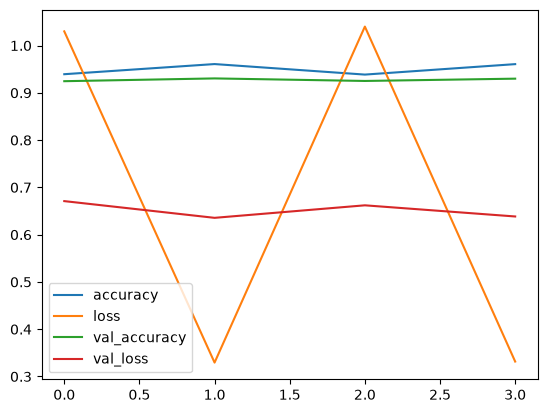

In [55]:
# csv 파일 로드 후 df으로 시각화
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('train_log.csv')
df = df.drop(columns = ['epoch']).plot() # epoch 제외한 나머지 시각화
plt.show()

In [56]:
# 모델 저장
decoder_teacher_forcing_model.save('decoder_teacher_forcing_model.keras')

In [57]:
# 모델 로드
from tensorflow.keras.models import load_model
decoder_teacher_forcing_model = load_model('decoder_teacher_forcing_model.keras')
decoder_teacher_forcing_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 101)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 90)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 101, 100)  │    320,100 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 90, 100)   │    828,900 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 512),     │  1,255,424 │ embedding_2[0][0] │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 90, 512), │  1,255,424 │ embedding_3[0][0… │
│                     │ (None, 512),      │            │ lstm_2[0][1],     │
│                     │ (None, 512)]      │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 90, 8289)  │  4,252,257 │ lstm_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,736,317 (90.55 MB)

 Trainable params: 7,912,105 (30.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,824,212 (60.36 MB)

In [58]:
# 추론 모델 (한 토큰씩 생성하는 추론모델)
decoder_hidden_state = layers.Input(shape = (LATENT_DIM,)) # 이전 시점 H(Hidden)
decoder_cell_state = layers.Input(shape = (LATENT_DIM,))   # 이전 시점 C(Cell State)
decoder_states_inputs = [decoder_hidden_state, decoder_cell_state] # (h, c) 상태 묶어 디코더 입력

decoder_single_input = layers.Input(shape = (1, ))         # 추론시 1개 토큰(ID)만 입력 (B,1)
x = ko_embedding_layer(decoder_single_input)               # (B, 1) -> (B, 1, EMBEDDING_DIM)

x, h, c = decoder_lstm(x, initial_state = decoder_states_inputs) # 입력토큰 + 이전상태(H, C)로 다음상태 계산
decoder_states = [h, c] # 다음 스텝에 넘길 상태 (h, c) 저장

decoder_outputs_ = decoder_dense(x) # (B, 1, kor_num_words + 1) 다음 단어 확률 분포 출력

# 추론용 디코더 모델(한 스텝)
decoder_inference_model = models.Model(
    inputs = [decoder_single_input] + decoder_states_inputs, # 입력 : 현재 토큰 + 이전 상태 (h,c)
    outputs = [decoder_outputs_] + decoder_states            # 출력 : 단어 분포 + 다음 상태(h, c)
)

decoder_inference_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 100)    │    828,900 │ input_layer_9[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 1, 512),  │  1,255,424 │ embedding_3[1][0… │
│                     │ (None, 512),      │            │ input_layer_7[0]… │
│                     │ (None, 512)]      │            │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 8289)   │  4,252,257 │ lstm_3[1][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,336,581 (24.17 MB)

 Trainable params: 6,336,581 (24.17 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:

# 번역함수 : 입력 영어 시퀀스를 인코더로 state로 변환 후, <sos>부터 시작해서 한 단어씩 생성하는 번역 함수
def translate(input_seq):
    encoder_states_value = encoder_model.predict(input_seq) # 인코더에서 초기 상태(h,c) 추출
    decoder_states_value = encoder_states_value             # 디코더 초기 삳ㅇ태로 설정

    sos_index = kor_tokenizer.word_index['<sos>']           # 시작토큰 ID
    eos_index = kor_tokenizer.word_index['<eos>']           # 종료토큰 ID

    target_seq = np.zeros((1,1))                            # 디코더 입력(현재 토큰) 자리 (B = 1, 길이 = 1)
    target_seq[0, 0] = sos_index  # 첫 입력 토큰은 <sos> 토큰으로 세팅

    output_sentences = [] # 생성된 단어(토큰)들을 담을 리스트

    for _ in range(kor_max_len): # 최대 길이는 한글 토킄 길이로 설정
        # (현재 토큰 + 이전 state)로 다음 토큰 분포와 state 예측

        output_tokens, h, c = decoder_inference_model.predict(
            [target_seq] + decoder_states_value
        )

        pred_proba = output_tokens[0, 0, :] # (1, 1, V) -> (V,)로 확률 벡터 추출
        pred_index = np.argmax(pred_proba)  # 가장 확률이 높은 단어 ID

        # 종료토큰 나오면 문장 생성 종료
        if pred_index == eos_index:
            break

        # 패딩 토큰이 아닐 경우에만
        if pred_index > 0:
            word = kor_tokenizer.index_Word[pred_index] # 실제 단어로 역변환
            output_sentences.append(word)                # 문장 토큰 하나씩 리스트에 추가

        target_seq[0,0] = pred_index # 이번 예측 토큰은 다음 스텝 입력으로 갱신
        decoder_state_Value = [h, c] # 현재 state도 다음 스텝 입력으로 갱신

    return " ".join(output_sentences)

In [60]:
print({
    word: index
    for word, index in kor_tokenizer.word_index.items()
    if "sos" in word.lower() or "eos" in word.lower()
})

{'<sos>': 2, '<eos>': 3}


In [61]:
def translate_eng2kor(eng_text):
    input_seq = eng_tokenizer.texts_to_sequences(eng_text)     # 영어 문장 리스트
    input_seq = pad_sequences(input_seq, maxlen = eng_max_len)
    return translate(input_seq)

eng_texts = [
    "My hair is black.", "French is interesting.", "I like bus.", "Let\'s study", "I ate sandwich"
]

for eng_text in eng_texts:
    kor_text = translate_eng2kor([eng_text]) # 배치 형태로 테스트 데이터 전달
    display(eng_text, kor_text)  # 번역결과 표시

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


AttributeError: 'Tokenizer' object has no attribute 'index_Word'